# LLM thematic annotation — full pipeline

Annotates every participant justification in `Qual Analysis - accounts_tidy.csv` with the
codes in `data/codebook.csv`, using **either** OpenAI GPT-5.1 **or** a local Qwen served by
Ollama.

The backend is a single setting. Both produce the *same* annotation schema — there are no
`gpt_*` or `qwen_*` columns anywhere — so the two runs differ only in their output filename
and in the `backend` / `model` columns. That makes them trivially concatenable and comparable.

Coding is **row-level**. Each row of the corpus receives the set of codebook codes that apply
to its justification; no spans, offsets or quotes are produced.

| step | what happens |
|---|---|
| 1 | load the corpus, the codebook and the adjudicated gold |
| 2 | pick a backend and build the system prompt from the codebook |
| 3 | dry-run on a handful of units and read the output |
| 4 | annotate the corpus, with an on-disk cache so an interrupt costs nothing |
| 5 | describe what the model produced against the human distribution |

Accuracy against the human-coded rounds is measured in `02_codebook_only_and_evaluation.ipynb`.

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from thematic_ai import RunConfig, annotate_units, evaluate_run
from thematic_ai.pipeline import load_workspace, make_system_prompt

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)
print(PROJECT_ROOT)

/Users/subham/Documents/thematicAnnotationAI


## 1. Inputs

Two files drive everything: `data/codebook.csv` and `data/adjudicated-all-rounds.csv`. The
adjudicated file is the gold standard — the codes agreed after the coders' disagreements were
resolved — and it is the only source of human labels the pipeline needs.

A **unit** is one account-level justification written by one participant, keyed as
`user_id::account`. That is the same key the annotation tool exported, so the corpus and the
adjudicated file join on it directly.

`load_workspace` reads both files, resolves every gold code against the codebook (raising if
the adjudicated file mentions a code the codebook does not define), collapses the export's
per-span rows to one row per unit × code, and splits the adjudicated units into a train half
and a test half.

In [12]:
bootstrap = RunConfig()  # paths only; the backend is chosen in the next section
ws = load_workspace(bootstrap)

display(ws.describe().to_frame("n"))
display(ws.codebook.to_frame().head(8)[["theme", "code", "definition"]])
display(ws.units.head(3)[["unit_id", "unit_text", "account_suspension", "num_messages"]])

FileNotFoundError: [Errno 2] No such file or directory: '/Users/subham/Documents/thematicAnnotationAI/data/annotations-all-rounds.csv'

## 2. Choose a backend

Change `BACKEND` and re-run the notebook top to bottom for the other model. Nothing else
needs to change.

**OpenAI** — `export OPENAI_API_KEY=sk-...` before launching Jupyter. `reasoning_effort`
accepts `none`, `low`, `medium`, `high` on GPT-5.1; `low` is a good default for coding tasks
of this size, and `none` is markedly cheaper and faster if you are annotating all 1,450 units.

**Ollama** — start the server with `ollama serve` and pull the model with
`ollama pull qwen3.5:latest`. Local generation runs at roughly 15–25 s per unit on an Apple
laptop, so the full corpus is an overnight job; the cache means you can stop and resume.

Both backends are constrained by the same JSON schema, whose `code` field is an enum of the
38 codebook codes. A model therefore *cannot* return a code that does not exist.

In [13]:
BACKEND = "openai"          # "ollama" | "openai"
MODEL = "gpt-5.1"                   # "" -> gpt-5.1 for openai, qwen3.5:latest for ollama
PROMPT_VARIANT = "calibrated"   # "codebook_only" | "few_shot" | "calibrated"

config = RunConfig(
    backend=BACKEND,
    model=MODEL,
    prompt_variant=PROMPT_VARIANT,
    few_shot_k=12,
    think=False,              # Ollama thinking models only
    temperature=0.0,
)   # reasoning_effort and retrieved_neighbours keep their tuned defaults
ws.config = config

from thematic_ai import get_backend

backend = get_backend(config)
print(backend.health_check())
print("run key:", config.run_key)

openai:gpt-5.1 ready
run key: openai__gpt-5.1__calibrated__k12__n10


## 3. The prompt

The system prompt is the coding manual: the task brief, then every code rendered with its
definition, its inclusion and exclusion criteria, and its example. With
`PROMPT_VARIANT="few_shot"` a block of worked examples taken from the *training* half of the
adjudicated units is appended — never from the test half, so evaluation stays honest.

In [14]:
system_prompt = make_system_prompt(ws, config)
print(f"{len(system_prompt):,} characters, {len(ws.codebook)} codes\n")
print(system_prompt[:2500])
print("\n... [codebook continues] ...\n")
print(system_prompt[-700:])

16,583 characters, 38 codes

You are an experienced qualitative researcher performing deductive thematic coding for a study on social media content moderation.

Participants reviewed a suspicious account, decided whether to suspend it, and wrote a short free-text justification. Your job is to assign codes from a fixed codebook to one such justification.

Rules:
1. Use ONLY the codes listed in the codebook below, spelled exactly as given. Never invent, merge or rename a code.
2. Assign every code the text supports. Most justifications get one or two codes; some get none, and a few get four or more.
3. Code what the participant actually wrote, not what you infer about the account. If the participant does not say it, do not code it.
4. A code is justified by evidence in the text. For each code, quote the shortest span of the justification that supports it, copied verbatim, character for character. If the code is supported by the justification as a whole rather than one span, return an emp

## 4. Dry run

Always read a handful of annotations before committing to the whole corpus.

Coding is **row-level**: the unit of analysis is the whole justification, and the answer for a
row is the set of codes that apply to it. No spans, offsets or quotes are produced. Each code
carries a confidence and a one-clause reason, which are there to be read during validation
rather than to locate text.

In [15]:
from thematic_ai.pipeline import make_context_builder

context_builder = make_context_builder(ws, config)   # None unless variant == "calibrated"

sample = ws.gold.head(5)
dry = annotate_units(
    sample, ws.codebook, config, system_prompt,
    backend=backend, context_builder=context_builder,
)

display(dry.annotations[["unit_id", "theme", "code", "confidence", "reason"]])
print("invalid codes dropped:", dry.dropped_codes or "none")

side_by_side = dry.units[["unit_id", "unit_text", "codes"]].merge(
    ws.gold[["unit_id", "gold_codes"]], on="unit_id"
)
side_by_side["gold_codes"] = side_by_side["gold_codes"].str.join("; ")
display(side_by_side.rename(columns={"codes": "model_codes", "gold_codes": "human_codes"}))

,unit_id,theme,code,confidence,reason
0,f6adc9c9-2d2e-4b3c-80c4-00eed10c6348::4,Type of offensiveness,No offensive content,0.99,Explicitly states there was nothing offensive in the comments
1,e84772f8-0104-4148-af15-e5424ff40caa::4,Type of offensiveness,Threats of violence,0.96,explicitly mentions a threat of physical harm as the basis for suspension
2,f5aa39ff-fa4a-477b-b01b-0e05b4255970::5,Type of offensiveness,No offensive content,0.96,explicitly states absence of offensive material
3,4e3a6cce-8e2f-4408-96e1-71048af70adb::5,Type of offensiveness,No offensive content,0.98,Explicitly states there was no offensive content
4,4e3a6cce-8e2f-4408-96e1-71048af70adb::5,Positive content,Personal opinions and thoughts,0.97,Describes the content as sharing thoughts on issues
5,7a345fe0-e245-4e5c-a2fc-b725eed72fa1::4,Patterns of behavior,One-off offensive,0.84,Describes a single problematic message against an otherwise acceptable pattern
6,7a345fe0-e245-4e5c-a2fc-b725eed72fa1::4,Justifications,Could be joking,0.96,Explicitly frames the comment as something that might be a joke
7,7a345fe0-e245-4e5c-a2fc-b725eed72fa1::4,Decision outcomes,Ban if behavior continues,0.90,States the user should be allowed to continue unless there is another incident


invalid codes dropped: none


,unit_id,unit_text,model_codes,human_codes
0,f6adc9c9-2d2e-4b3c-80c4-00eed10c6348::4,None of the comments were offensive. There was no reason to suspend.,No offensive content,No offensive content
1,e84772f8-0104-4148-af15-e5424ff40caa::4,Threatening physical harm is grounds to suspend someone in my book.,Threats of violence,Threats of violence
2,f5aa39ff-fa4a-477b-b01b-0e05b4255970::5,They never said awful stuff and seem decent,No offensive content,No offensive content
3,4e3a6cce-8e2f-4408-96e1-71048af70adb::5,The messages in this account was sharing thoughts on issues and was not being offensive,No offensive content; Personal opinions and thoughts,No offensive content; Personal opinions and thoughts
4,7a345fe0-e245-4e5c-a2fc-b725eed72fa1::4,"They had a slip up on message 3 which could be taken as a threat, but I do not know th...",One-off offensive; Could be joking; Ban if behavior continues,Appeal to intent; Ban if behavior continues; Could be joking; Expressed uncertainty; O...


## 5. Annotate the corpus

`UNIT_SELECTION` controls what gets coded:

- `all` — every one of the 1,450 justifications
- `unlabelled` — only the units no human has coded, which is usually what you actually want
  once the model has been validated
- `gold` / `train` / `test` — the human-coded units, for evaluation

Set `LIMIT` to a small number for a rehearsal. Every answer is cached under
`outputs/cache/` keyed by the model, the prompt and its settings, so re-running is free and
an interrupted run resumes where it stopped. Failures are deliberately *not* cached, so they
are retried on the next run.

In [16]:
UNIT_SELECTION = "all"   # "all" | "unlabelled" | "gold" | "train" | "test"
LIMIT = 25               # 0 = no limit

selection = {
    "all": ws.units,
    "unlabelled": ws.unlabelled,
    "gold": ws.gold,
    "train": ws.train,
    "test": ws.test,
}[UNIT_SELECTION]
if LIMIT:
    selection = selection.head(LIMIT)

print(f"annotating {len(selection)} units with {config.backend}:{config.model}")
run = annotate_units(
    selection,
    ws.codebook,
    config,
    system_prompt,
    backend=backend,
    context_builder=context_builder,
    progress=lambda done, total: print(f"  {done}/{total}", end="\r"),
)

paths = run.save()
print(f"\n{len(run.annotations)} code assignments over {len(run.units)} units, {run.n_failed} failed")
for name, path in paths.items():
    print(f"  {name}: {path.relative_to(PROJECT_ROOT)}")

annotating 25 units with openai:gpt-5.1
  25/25
38 code assignments over 25 units, 0 failed
  annotations: outputs/annotations__openai__gpt-5.1__calibrated__k12__n10.csv
  units: outputs/annotations__openai__gpt-5.1__calibrated__k12__n10__units.csv
  wide: outputs/annotations__openai__gpt-5.1__calibrated__k12__n10__wide.csv
  manifest: outputs/annotations__openai__gpt-5.1__calibrated__k12__n10__manifest.json


## 6. What the model produced

Four files are written per run, all prefixed with the run key
(`{backend}__{model}__{prompt_variant}`):

| file | contents |
|---|---|
| `annotations__<key>.csv` | long format, one row per unit × code, mirroring the human annotation export |
| `annotations__<key>__units.csv` | one row per unit: codes, note, status, latency, tokens |
| `annotations__<key>__wide.csv` | binary unit × code matrix |
| `annotations__<key>__manifest.json` | the exact config and system prompt used |

The most useful sanity check is the code frequency distribution. A model that has understood
the codebook applies rare codes rarely; one that has not tends to spray a handful of generic
codes across everything.

,model,human_adjudicated,model_share,human_share
code,,,,
Hate speech and offensive language,10,115,0.263,0.309
Threats of violence,7,50,0.184,0.134
No offensive content,6,41,0.158,0.110
Consistent offensive behavior,6,26,0.158,0.070
Troll or bot,1,1,0.026,0.003
Not too offensive,1,7,0.026,0.019
Appeal to intent,1,4,0.026,0.011
Mix of offensive and non-offensive,1,4,0.026,0.011
Normal behavior,1,12,0.026,0.032


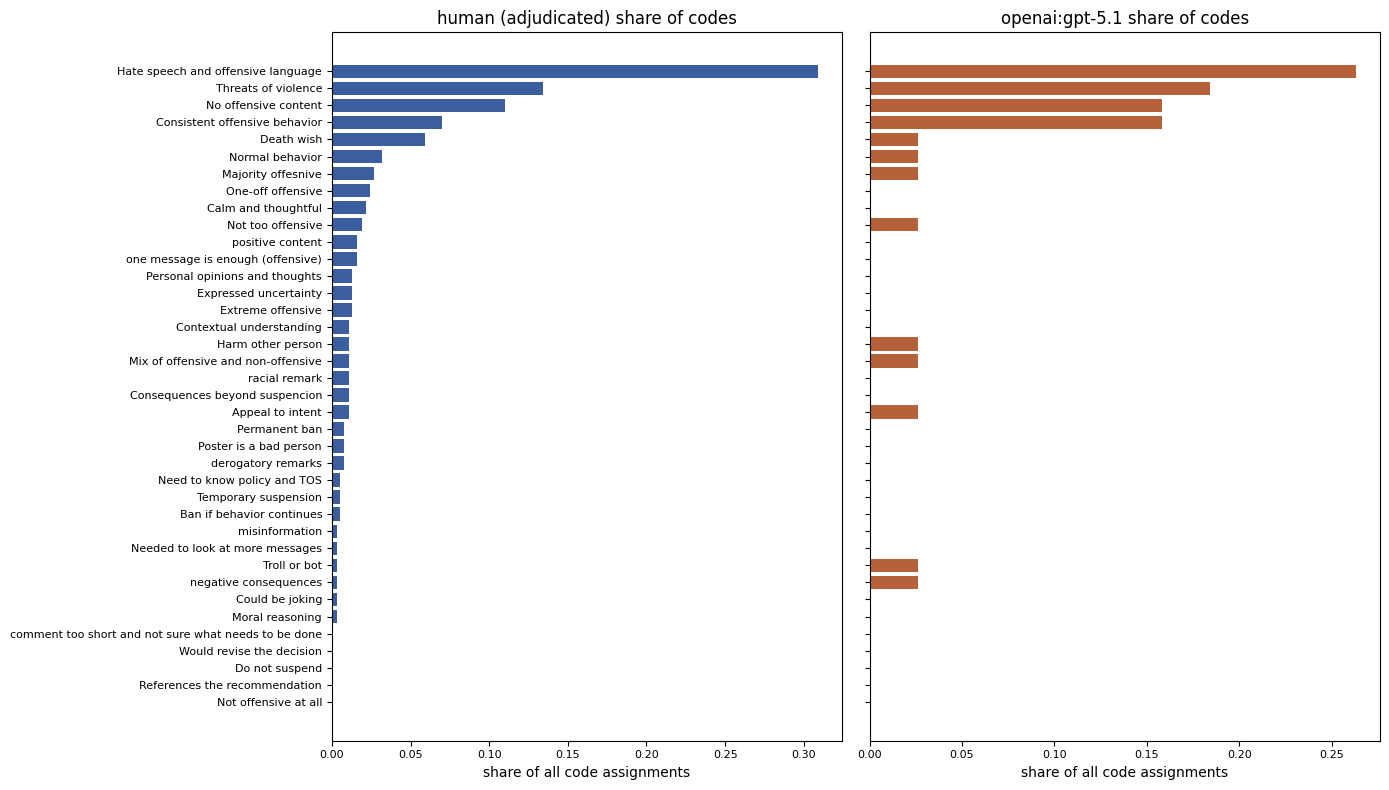

codes per unit — model: 1.52 | human gold: 1.71


In [17]:
model_freq = run.annotations["code"].value_counts().rename("model")
human_freq = ws.adjudicated["code"].value_counts().rename("human_adjudicated")

freq = (
    pd.concat([model_freq, human_freq], axis=1)
    .fillna(0)
    .astype(int)
    .reindex(ws.codebook.names)
    .fillna(0)
    .astype(int)
)
freq["model_share"] = (freq["model"] / max(freq["model"].sum(), 1)).round(3)
freq["human_share"] = (freq["human_adjudicated"] / max(freq["human_adjudicated"].sum(), 1)).round(3)
display(freq.sort_values("model", ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
plotted = freq.sort_values("human_share", ascending=True)
axes[0].barh(plotted.index, plotted["human_share"], color="#3b5f9e")
axes[0].set_title("human (adjudicated) share of codes")
axes[1].barh(plotted.index, plotted["model_share"], color="#b5623a")
axes[1].set_title(f"{config.backend}:{config.model} share of codes")
for ax in axes:
    ax.set_xlabel("share of all code assignments")
    ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

print("codes per unit — model:", round(run.units["n_codes"].mean(), 2),
      "| human gold:", round(ws.gold["n_gold_codes"].mean(), 2))

## 7. Quick score, if the run overlapped the gold units

Only meaningful when `UNIT_SELECTION` was `gold`, `train`, `test` or `all`. The proper
evaluation, with a held-out test split and a human baseline, lives in notebook 02.

In [18]:
overlap = [u for u in run.units["unit_id"] if u in ws.gold_labels]

if overlap:
    result = evaluate_run(run, ws.gold_labels, ws.codebook)
    display(pd.Series(result.overall).to_frame("value").round(4))
    display(result.per_code[result.per_code["support_gold"] > 0].head(12))
else:
    print(f"none of the {len(run.units)} annotated units are in the gold set — nothing to score")

,value
n_units,2.0
n_codes_evaluated,38.0
gold_labels,2.0
pred_labels,2.0
micro_precision,1.0
micro_recall,1.0
micro_f1,1.0
macro_f1_present_codes,1.0
macro_kappa_present_codes,1.0
weighted_f1,1.0


,code,support_gold,support_pred,tp,fp,fn,tn,precision,recall,f1,percent_agreement,cohens_kappa
0,No offensive content,1,1,1,0,0,1,1.0,1.0,1.0,1.0,1.0
1,Threats of violence,1,1,1,0,0,1,1.0,1.0,1.0,1.0,1.0


## 8. Running the other backend

Set `BACKEND = "openai"` in section 2 and re-run. The output lands in a separate file
(`annotations__openai__gpt-5.1__codebook_only.csv`) with identical columns, so the two runs
stack directly:

```python
gpt = pd.read_csv(PROJECT_ROOT / "outputs/annotations__openai__gpt-5.1__codebook_only.csv")
qwen = pd.read_csv(PROJECT_ROOT / "outputs/annotations__ollama__qwen3.5-latest__codebook_only.csv")
both = pd.concat([gpt, qwen], ignore_index=True)
both.groupby(["model", "code"]).size().unstack(fill_value=0)
```

The equivalent from a terminal, which is the better option for a full-corpus run:

```bash
export OPENAI_API_KEY=sk-...
python scripts/run_annotate.py --backend openai --model gpt-5.1 --units all
python scripts/run_annotate.py --backend ollama --model qwen3.5:latest --units all
```